In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.decomposition import PCA


#### Task 1:Exploratory Data Analysis

In [2]:
# Load Dataset & Basic Exploration
# Load dataset
file_path = "Pharma_Industry.csv"
df = pd.read_csv(file_path)

# Basic info
print(df.head())
print(df.info())
print(df.describe(include='all'))


   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 

In [3]:
# Check Missing Values
print(df.isnull().sum())


Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64


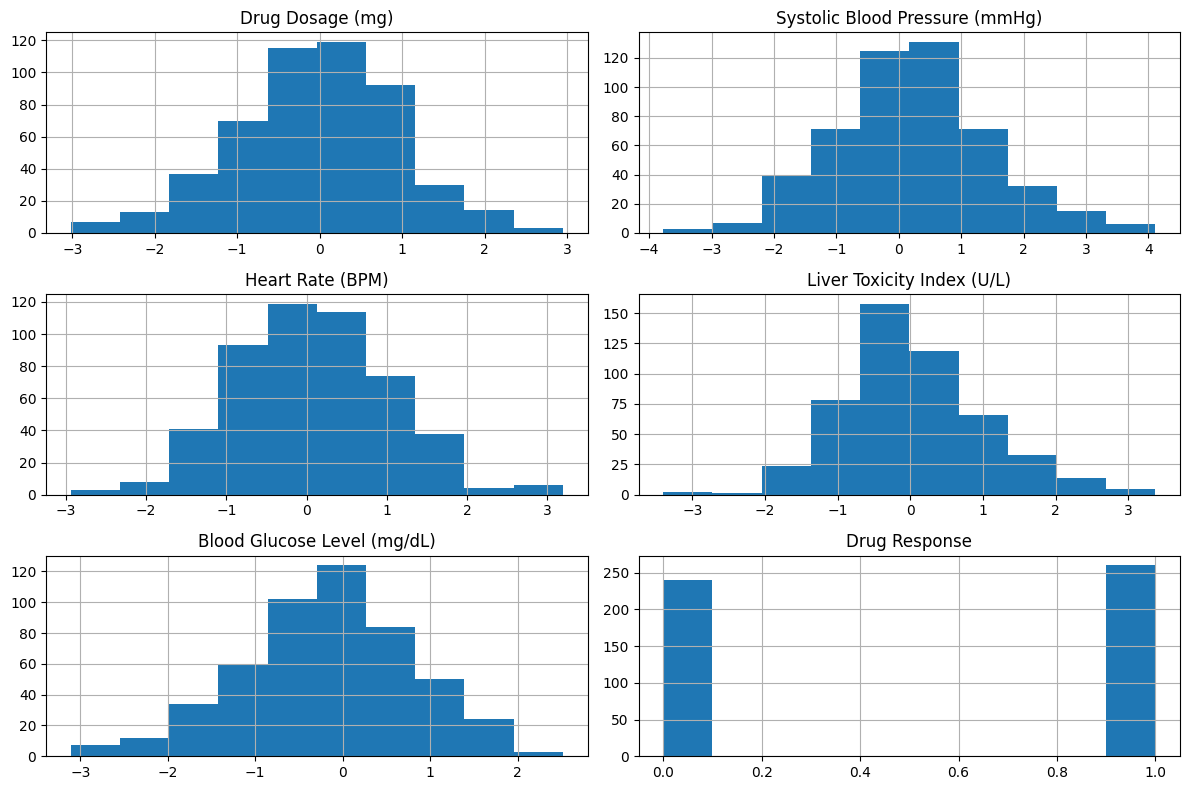

In [4]:
# Feature Distribution
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()


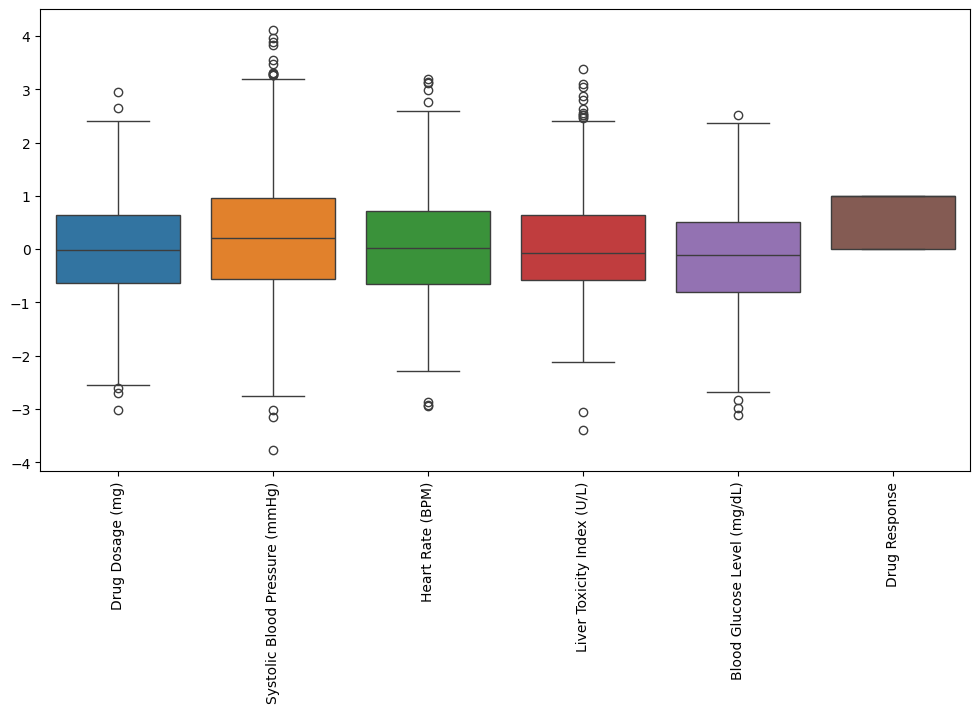

In [5]:
# Boxplots
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.show()


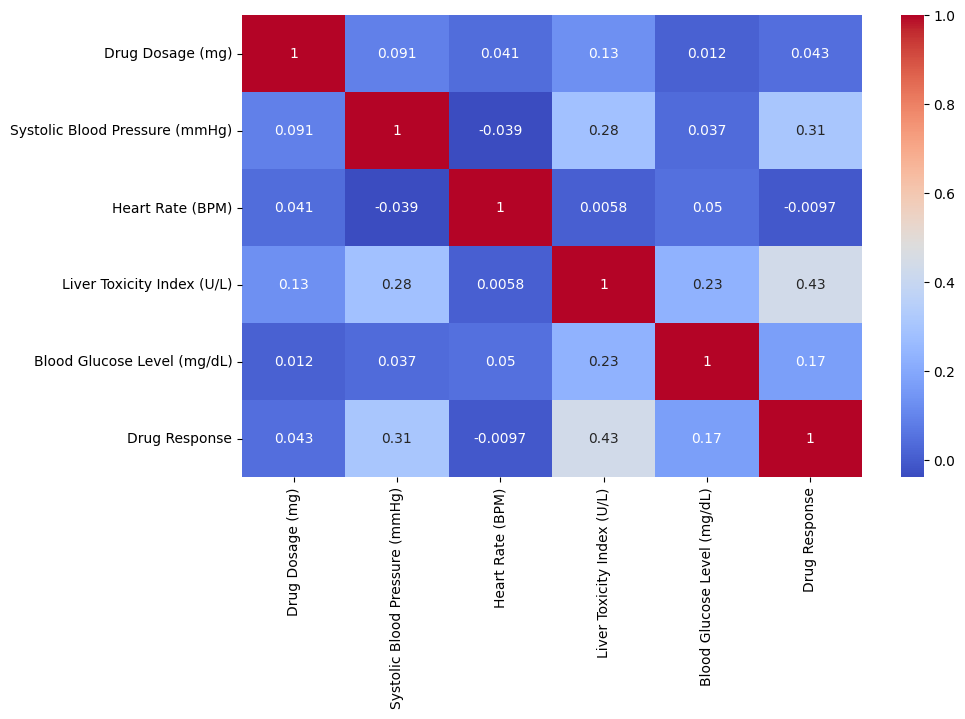

In [6]:
# Correlation Analysis
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True, cmap='coolwarm')
plt.show()


#### Task 2: data Processing

In [ ]:
# Encode Categorical Columns
# Import required libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder

#  Display dataset BEFORE encoding
print("Dataset BEFORE encoding:\n")
print(df.head())
print("\nData types BEFORE encoding:\n")
print(df.dtypes)

# Encode categorical (object) columns
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

#  Display dataset AFTER encoding
print("\nDataset AFTER encoding:\n")
print(df.head())
print("\nData types AFTER encoding:\n")
print(df.dtypes)

# Show label mappings 
print("\nLabel Encoding Mappings:")
for col, le in label_encoders.items():
    print(f"{col}: {list(le.classes_)}")


Dataset BEFORE encoding:

   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  

Data types BEFORE encoding:

Drug Dosage (mg)                  float64
Systoli

In [10]:
# Feature Target split
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("FEATURES (X):")
print(X.head())

print("\nTARGET (y):")
print(y.head())


FEATURES (X):
   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  
0                    0.258286                    -0.792011  
1                    2.866786                    -0.719447  
2                   -0.325370                     0.191314  
3                    0.975286                    -0.823355  
4                    1.896015                    -0.960130  

TARGET (y):
0    1
1    1
2    0
3    1
4    1
Name: Drug Response, dtype: int64


In [11]:
# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

print("\n rows of X_train:")
print(X_train.head())

print("\n values of y_train:")
print(y_train.head())


Training Features Shape: (375, 5)
Testing Features Shape: (125, 5)
Training Target Shape: (375,)
Testing Target Shape: (125,)

 rows of X_train:
     Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
311         -2.211862                       -1.531498          1.533434   
423          0.473632                       -0.053317         -0.926381   
48           0.200569                        1.018626          1.148637   
433         -0.787784                       -1.584586         -0.620848   
354          1.217159                        0.320166          1.521316   

     Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  
311                   -0.373334                     0.543145  
423                   -0.317874                     0.240809  
48                    -3.067864                    -3.110431  
433                    1.098557                    -1.505045  
354                   -0.502307                    -0.759385  

 values of y_train:
311  

In [15]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before Scaling ( rows of X_train):")
print(X_train.head())

print("\nAfter Scaling (rows of X_train_scaled):")
print(X_train_scaled[:5])

print("\nShape of Scaled Training Data:", X_train_scaled.shape)
print("Shape of Scaled Testing Data:", X_test_scaled.shape)





Before Scaling ( rows of X_train):
     Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
311         -2.211862                       -1.531498          1.533434   
423          0.473632                       -0.053317         -0.926381   
48           0.200569                        1.018626          1.148637   
433         -0.787784                       -1.584586         -0.620848   
354          1.217159                        0.320166          1.521316   

     Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  
311                   -0.373334                     0.543145  
423                   -0.317874                     0.240809  
48                    -3.067864                    -3.110431  
433                    1.098557                    -1.505045  
354                   -0.502307                    -0.759385  

After Scaling (rows of X_train_scaled):
[[-2.29158924 -1.32483407  1.49782911 -0.42267978  0.69172356]
 [ 0.47527745 -0.17654663 -0.998

#### Task 3:Visualization

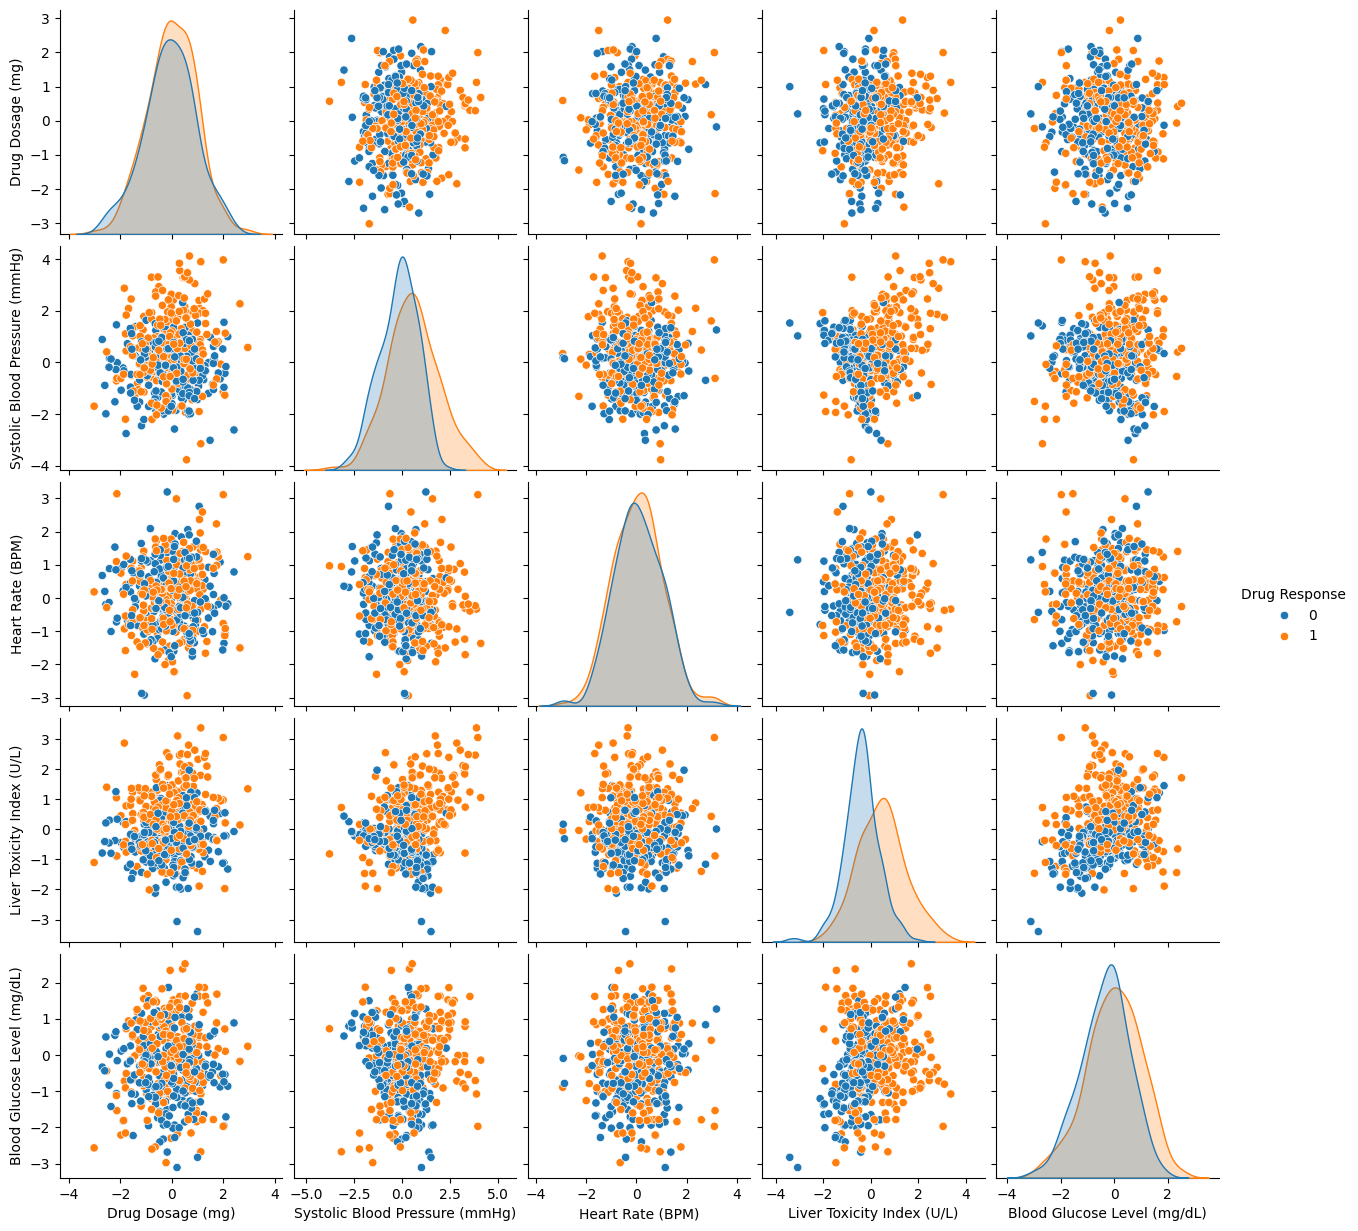

In [17]:
# Pair Plot
sns.pairplot(df, hue=df.columns[-1])
plt.show()


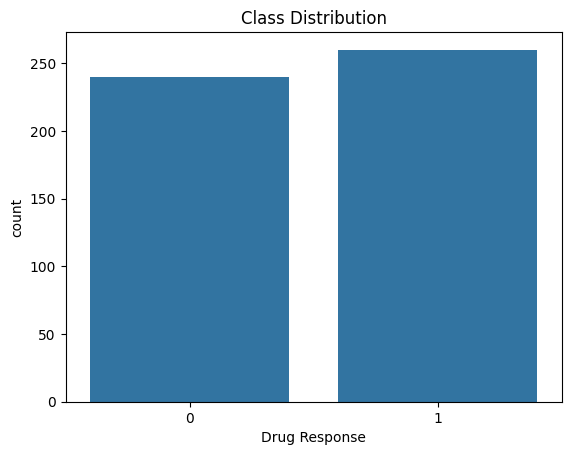

In [19]:
# Class Distribution
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()


#### Task 4:SVM Implementation

In [20]:
# Train Basic SVM
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)


SVC(kernel='linear', random_state=42)

In [21]:
# Model Evaluation
y_pred = svm_linear.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.728

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.78      0.73        60
           1       0.77      0.68      0.72        65

    accuracy                           0.73       125
   macro avg       0.73      0.73      0.73       125
weighted avg       0.73      0.73      0.73       125


Confusion Matrix:
 [[47 13]
 [21 44]]


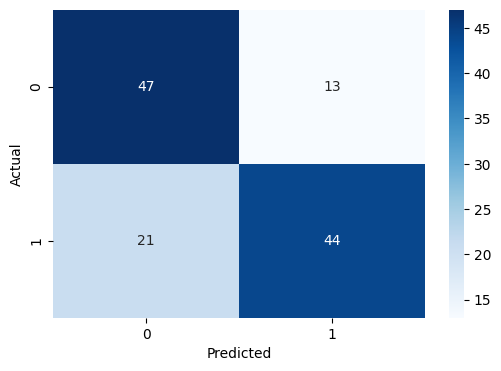

In [22]:
# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#### Task 5:Visualizations Of SVm

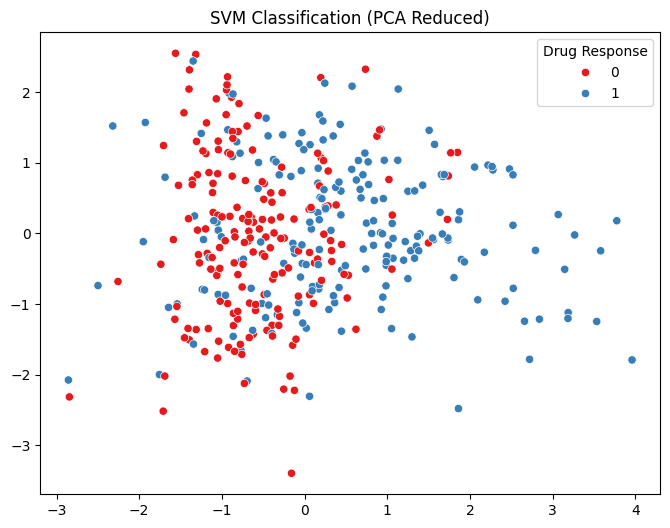

In [23]:
# PCA-Based decision boundary
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

svm_vis = SVC(kernel='linear')
svm_vis.fit(X_pca, y_train)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1],
                hue=y_train, palette='Set1')
plt.title("SVM Classification (PCA Reduced)")
plt.show()


#### Task 6:Parameter Tuning and Optimization

In [24]:
 param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)


Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 0.76


In [25]:
# Evaluate Optimized model
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_best))


Optimized Accuracy: 0.752


#### Task 7: Comparison And Analysis

In [26]:
kernels = ['linear', 'poly', 'rbf']
for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train_scaled, y_train)
    y_pred_k = model.predict(X_test_scaled)
    print(f"{k.upper()} Kernel Accuracy:",
          accuracy_score(y_test, y_pred_k))


LINEAR Kernel Accuracy: 0.728
POLY Kernel Accuracy: 0.688
RBF Kernel Accuracy: 0.752


In [ ]:
# Analysis:

# Strengths of SVM:
# Effective in high-dimensional data
# Works well with clear class margins
# Kernel trick enables non-linear classification

# Weaknesses:
# Sensitive to parameter tuning
# Computationally expensive for large datasets
# Harder to interpret than linear models

# Practical Implications:
# Suitable for drug response prediction
# Helps in personalized medicine
# Supports decision-making in pharma analytics